# 02 — Clustering & Cell Type Annotation

**Input:** `data/processed/adata_qc.h5ad`  
**Output:** `data/processed/adata_annotated.h5ad`

---

## What this notebook does
1. Build neighbour graph on Harmony-corrected PCA
2. UMAP embedding
3. Leiden clustering
4. Annotate clusters using canonical haematopoietic marker genes
5. Score LSC stemness signature per cell
6. Visualise by cell type, condition, and patient

---

## AML cell type biology
AML disrupts normal haematopoiesis — instead of HSCs differentiating into mature blood cells,
leukaemic blasts are blocked at an immature stage. scRNA-seq reveals which normal haematopoietic
cell states are present in each sample and which are absent or distorted.

Key cell types to identify:
- **HSC-like** — most primitive; enriched in relapse/resistant AML (leukaemic stem cells)
- **GMP-like** — granulocyte-monocyte progenitors; common AML blast state
- **ProMono/Mono-like** — more differentiated; varied treatment sensitivity
- **T/NK/B cells** — non-malignant immune cells; important for microenvironment analysis

In [1]:
%matplotlib inline
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Reproducible repo root
repo_root = os.path.dirname(os.getcwd())
sys.path.insert(0, repo_root)
from scripts.utils.config import *

# Fix result paths
RESULTS_CLUST = os.path.join(repo_root, 'results', 'clustering')
os.makedirs(RESULTS_CLUST, exist_ok=True)

sc.settings.verbosity = 2
np.random.seed(RANDOM_SEED)

print('Libraries loaded.')
print('Repo root:', os.path.basename(repo_root))

Libraries loaded.
Repo root: aml-treatment-resistance


In [2]:
# Load QC-processed object from notebook 01
adata = sc.read_h5ad(os.path.join(repo_root, 'data', 'processed', 'adata_qc.h5ad'))

print(adata)
print(f'\nEmbeddings available: {list(adata.obsm.keys())}')
print(f'\nGroups:')
print(adata.obs['group'].value_counts())

AnnData object with n_obs × n_vars = 38316 × 21582
    obs: 'sample_id', 'patient_id', 'condition', 'group', 'day', 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'raw_counts_per_cell', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'group_colors', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    layers: 'counts'

Embeddings available: ['X_pca', 'X_pca_harmony']

Groups:
group
AML_Diagnosis    15667
AML_Treated      14988
Healthy           7661
Name: count, dtype: int64


## 1. Neighbour graph & UMAP

In [4]:
# ── NEIGHBOUR GRAPH 
# Using Harmony-corrected PCA embedding — corrects for sample batch effects
# while preserving biological signal between groups

sc.pp.neighbors(
    adata,
    n_neighbors  = 15,
    n_pcs        = 20,        # elbow plot showed variance levels off at ~PC20
    use_rep      = 'X_pca_harmony',
    random_state = RANDOM_SEED
)

print('Neighbour graph built.')
print(f'  n_neighbors: 15')
print(f'  n_pcs: 20 (based on elbow plot)')
print(f'  embedding: X_pca_harmony (Harmony batch-corrected)')

computing neighbors
    finished (0:00:15)
Neighbour graph built.
  n_neighbors: 15
  n_pcs: 20 (based on elbow plot)
  embedding: X_pca_harmony (Harmony batch-corrected)


In [5]:
# ── UMAP ───────────────────────────────────────────────────────────────────────
sc.tl.umap(adata, min_dist=0.3, random_state=RANDOM_SEED)

print('UMAP computed.')
print(f'Embedding shape: {adata.obsm["X_umap"].shape}')

computing UMAP
    finished (0:01:19)
UMAP computed.
Embedding shape: (38316, 2)


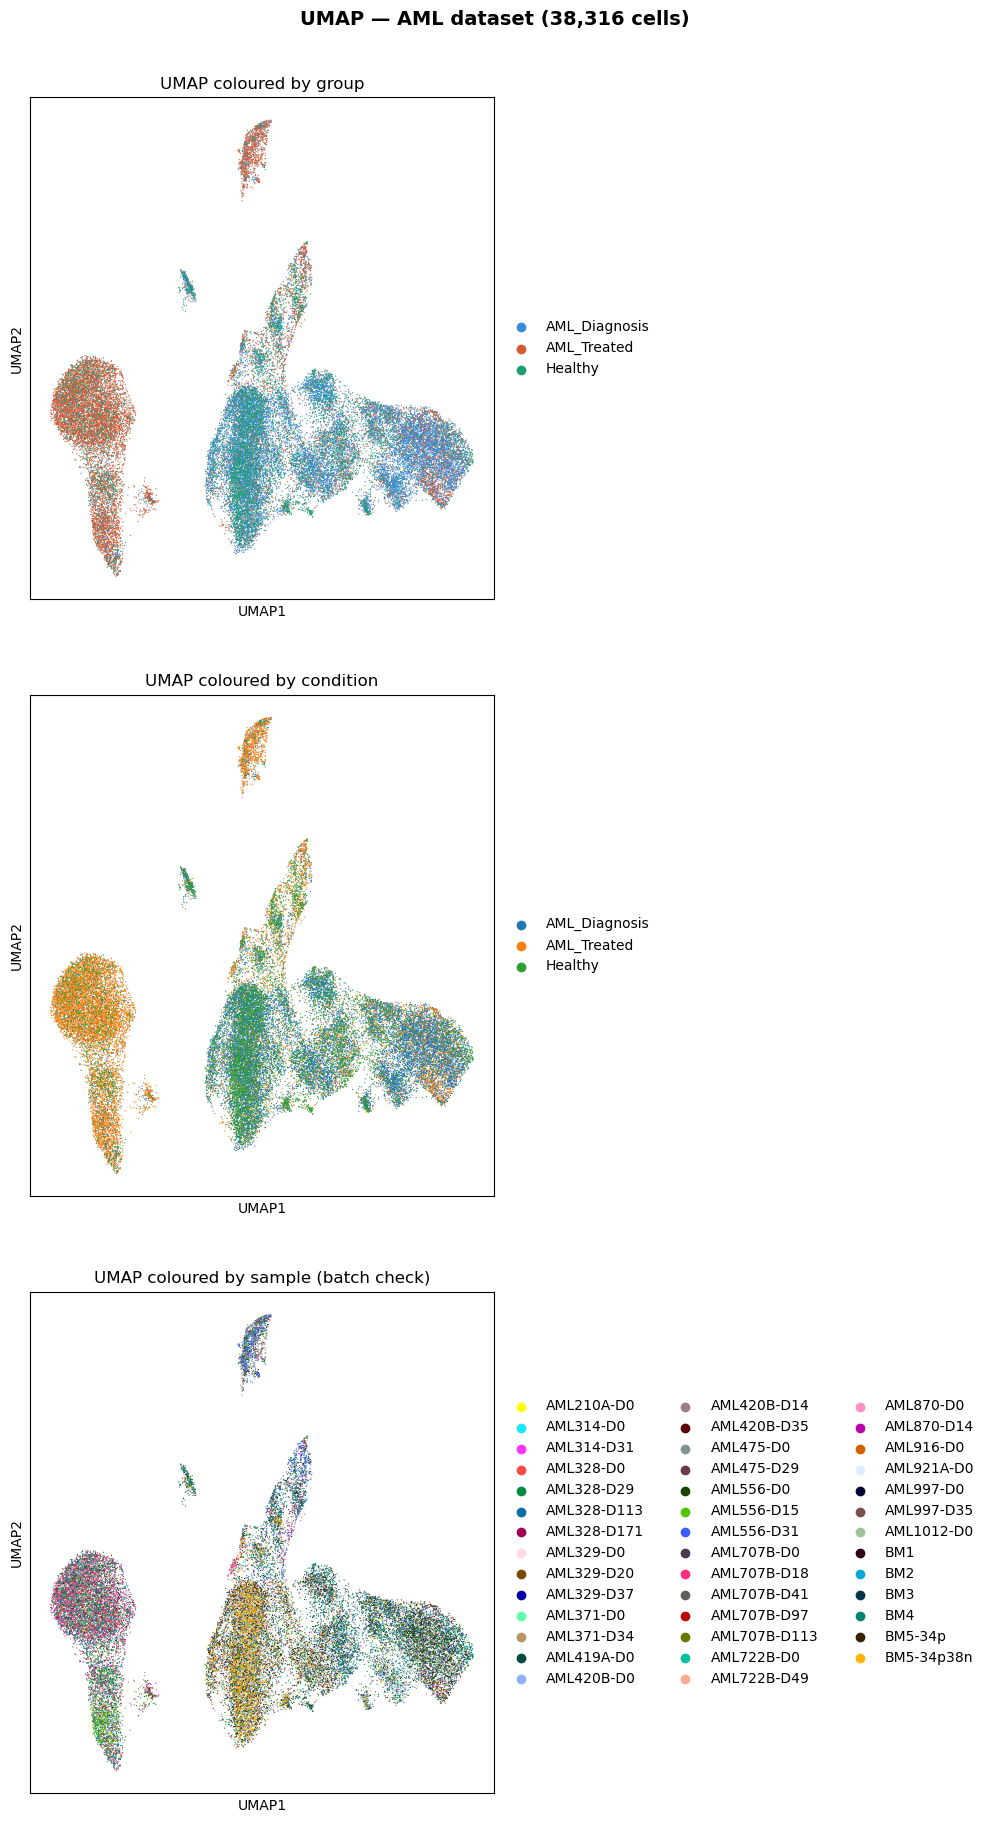

UMAP plot saved to results/clustering/


In [9]:
# ── UMAP PLOTS — vertical layout ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1 — by group
sc.pl.umap(adata, color='group', ax=axes[0], show=False,
           palette={'Healthy'       : '#1D9E75',
                    'AML_Diagnosis' : '#378ADD',
                    'AML_Treated'   : '#D85A30'},
           title='UMAP coloured by group',
           legend_loc='right margin',
           size=3)

# Plot 2 — by condition  
sc.pl.umap(adata, color='condition', ax=axes[1], show=False,
           title='UMAP coloured by condition',
           legend_loc='right margin',
           size=3)

# Plot 3 — by sample
sc.pl.umap(adata, color='sample_id', ax=axes[2], show=False,
           title='UMAP coloured by sample (batch check)',
           legend_loc='right margin',
           size=3)

plt.suptitle('UMAP — AML dataset (38,316 cells)', 
             fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout(h_pad=4)
plt.savefig(os.path.join(RESULTS_CLUST, 'umap_group_condition_sample.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('UMAP plot saved to results/clustering/')

## UMAP Results & Interpretation

### What is UMAP?
UMAP (Uniform Manifold Approximation and Projection) reduces 
the 20-dimensional Harmony-corrected PCA embedding down to 
2 dimensions for visualisation. Cells that are transcriptionally 
similar cluster together — each "island" represents a distinct 
cell population.

### Plot 1 — Coloured by group
The UMAP shows clear separation between the three groups:

- **Healthy (green)** — forms a distinct region, separate from 
  AML cells. Normal bone marrow has a different transcriptional 
  programme from leukaemic cells.
- **AML_Diagnosis (blue)** — widely distributed across multiple 
  islands, reflecting the heterogeneity of AML blasts at diagnosis.
- **AML_Treated (orange)** — partially overlaps with diagnosis 
  cells but shows enrichment in specific regions, suggesting 
  chemotherapy selects for particular cell states.

The small isolated cluster at the top likely represents a 
rare cell population — possibly erythroid or plasma cells.

### Plot 2 — Coloured by condition
Confirms the same pattern as Plot 1. The three conditions 
occupy distinct but partially overlapping regions, indicating 
shared cell types across groups with condition-specific enrichments.

### Plot 3 — Coloured by sample (batch check)
This is the most important quality control plot for batch correction.

**Good sign:** Cells from different samples are well mixed 
within each cluster — no single sample dominates any region. 
This confirms Harmony batch correction worked correctly — 
technical variation between samples has been removed while 
biological variation between groups is preserved.

**If batch correction had failed:** Each sample would form 
its own isolated island regardless of cell type, making 
downstream analysis unreliable.

### Key observation
The separation between Healthy and AML cells is biologically 
meaningful — AML disrupts normal haematopoiesis, replacing 
normal differentiated cells with transcriptionally distinct 
leukaemic blasts. The partial overlap between AML_Diagnosis 
and AML_Treated suggests some cell states persist through 
chemotherapy while others are selectively eliminated or enriched.

## 2. Leiden clustering

In [15]:
# ── LEIDEN CLUSTERING 
sc.tl.leiden(adata, resolution=0.5, random_state=RANDOM_SEED)

print(f'Number of clusters: {adata.obs["leiden"].nunique()}')
print('\nCells per cluster:')
print(adata.obs['leiden'].value_counts().sort_index())


running Leiden clustering
    finished (0:00:06)
Number of clusters: 11

Cells per cluster:
leiden
0     10053
1      7176
2      5993
3      4522
4      2661
5      2394
6      2206
7      1486
8      1225
9       376
10      224
Name: count, dtype: int64


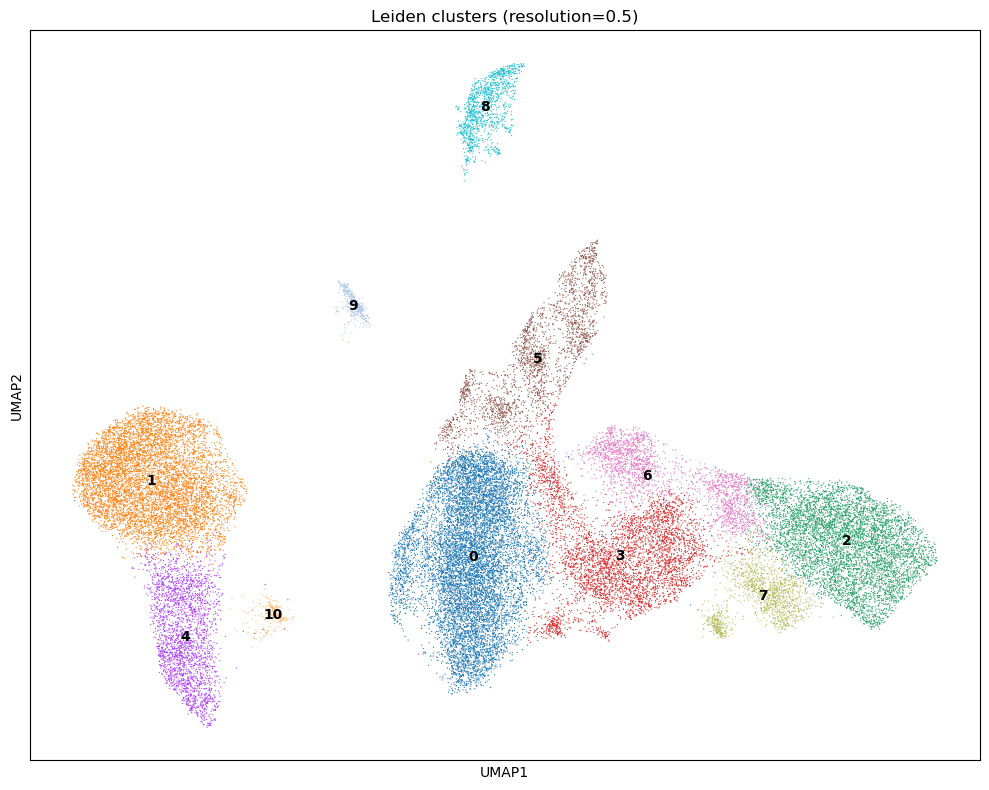

Leiden cluster UMAP saved.
Total clusters: 11


In [17]:
# ── UMAP — coloured by Leiden clusters 
fig, ax = plt.subplots(figsize=(10, 8))

sc.pl.umap(adata, color='leiden', 
           ax=ax, show=False,
           legend_loc='on data',
           legend_fontsize=10,
           title='Leiden clusters (resolution=0.5)',
           size=3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_CLUST, 'umap_leiden_clusters.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Leiden cluster UMAP saved.')
print(f'Total clusters: {adata.obs["leiden"].nunique()}')


#### Leiden clustering assigned 11 clusters (0–10) to our 38,316 cells. Each cluster number is an arbitrary label the biology comes from inspecting which genes are highly expressed in each cluster.


### Spatial interpretation of them UMAP

**Left side — lymphoid compartment (separate from AML cells)**
- **Cluster 1** — large, round, tightly packed island. Very distinct 
  from the rest.
- **Cluster 4** — connected below cluster 1.
- **Cluster 10** — small isolated population.
**Central/right — myeloid compartment (the AML landscape)**
- **Cluster 0** — largest cluster (10,053 cells), central position. 
- **Cluster 3** — adjacent to cluster 0.
- **Cluster 5** — elongated vertical structure, suggesting a 
  differentiation trajectory.
- **Cluster 6** — sits between clusters 3 and 2
- **Cluster 2** — far right, more separated.
- **Cluster 7** — small cluster between 2 and 3

**Isolated clusters**
- **Cluster 8** — completely isolated at the top.
- **Cluster 9** — small, mid-left isolation.

### Why are some clusters isolated?
Isolated clusters (8, 9, 10) are transcriptionally very different 
from the main cell populations — their gene expression programmes 
share almost nothing with myeloid or lymphoid cells, so UMAP places 
them far away from the main body of cells.


## 3. Cell type annotation

categories: 0, 1, 2, etc.
var_group_labels: HSC/Progenitor, GMP-like, ProMono-like, etc.


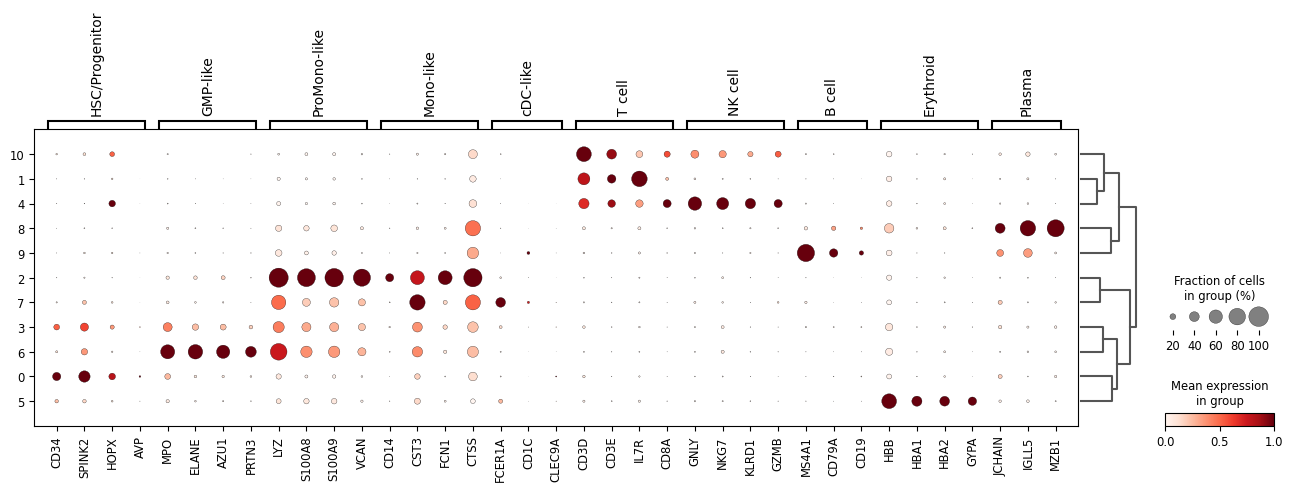

Dotplot saved.


In [21]:
# ── MARKER GENE DOTPLOT 
marker_genes = {
    'HSC/Progenitor' : ['CD34', 'SPINK2', 'HOPX', 'AVP'],
    'GMP-like'       : ['MPO', 'ELANE', 'AZU1', 'PRTN3'],
    'ProMono-like'   : ['LYZ', 'S100A8', 'S100A9', 'VCAN'],
    'Mono-like'      : ['CD14', 'CST3', 'FCN1', 'CTSS'],
    'cDC-like'       : ['FCER1A', 'CD1C', 'CLEC9A'],
    'T cell'         : ['CD3D', 'CD3E', 'IL7R', 'CD8A'],
    'NK cell'        : ['GNLY', 'NKG7', 'KLRD1', 'GZMB'],
    'B cell'         : ['MS4A1', 'CD79A', 'CD19'],
    'Erythroid'      : ['HBB', 'HBA1', 'HBA2', 'GYPA'],
    'Plasma'         : ['JCHAIN', 'IGLL5', 'MZB1'],
}

sc.pl.dotplot(
    adata,
    var_names      = marker_genes,
    groupby        = 'leiden',
    dendrogram     = True,
    standard_scale = 'var',
    show           = False
)
plt.savefig(os.path.join(RESULTS_CLUST, 'dotplot_marker_genes.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Dotplot saved.')

## Dotplot Interpretation
- **Rows** = Leiden clusters (0–10)
- **Columns** = canonical marker genes grouped by cell type
- **Dot size** = percentage of cells in that cluster expressing the gene
- **Dot colour** = mean expression level (dark red = high, light = low)

A cluster is assigned a cell type when it shows large, dark dots 
under that cell type's marker genes and small/empty dots elsewhere.

### Cluster assignments

| Cluster | Key markers expressed | Cell type assigned |
|---------|----------------------|-------------------|
| 0 | CD34, S100A8, S100A9 | ProMono-like AML blast |
| 1 | CD3D, CD3E, IL7R | T cell |`
| 2 | LYZ, S100A8, S100A9, VCAN, CD14 | Mono-like |
| 3 | CD34, MPO, LYZ | GMP-like AML blast |
| 4 | CD3D, GNLY, NKG7, KLRD1, GZMB | NK / Cytotoxic T cell |
| 5 | HBB, HBA1, HBA2 | Erythroid |
| 6 | MPO, ELANE, AZU1, PRTN3 | GMP-like (immature blast) |
| 7 | LYZ, S100A8, MPO | ProMono-like |
| 8 | FCER1A, CLEC9A, CD1C | cDC (dendritic cells) |
| 9 | MS4A1, CD79A | B cell |
| 10 | CD3D, CD3E, NKG7, GZMB | T cell / NK cell |


In [31]:
# ── CELL TYPE ANNOTATION 
cluster_annotations = {
    '0'  : 'ProMono-like',
    '1'  : 'T cell',
    '2'  : 'Mono-like',
    '3'  : 'GMP-like',
    '4'  : 'NK cell',
    '5'  : 'Erythroid',
    '6'  : 'GMP-like',
    '7'  : 'ProMono-like',
    '8'  : 'cDC',
    '9'  : 'B cell',
    '10' : 'T cell',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotations)

print('Cell type counts:')
print(adata.obs['cell_type'].value_counts())

Cell type counts:
cell_type
ProMono-like    11539
T cell           7400
GMP-like         6728
Mono-like        5993
NK cell          2661
Erythroid        2394
cDC              1225
B cell            376
Name: count, dtype: int64


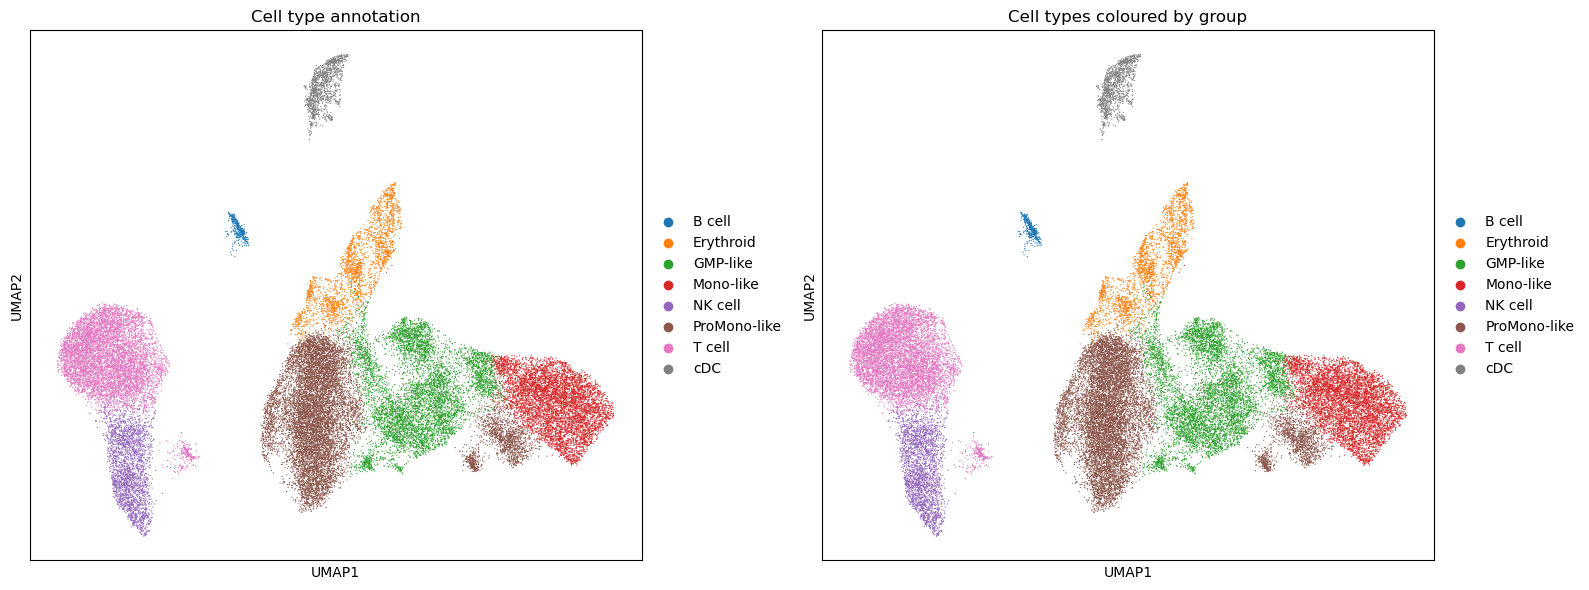

Annotated UMAP saved.


In [32]:
# ── UMAP — annotated cell types 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — cell types
sc.pl.umap(adata, color='cell_type',
           ax=axes[0], show=False,
           legend_loc='right margin',
           title='Cell type annotation',
           size=3)

# Plot 2 — cell types split by group
sc.pl.umap(adata, color='cell_type',
           ax=axes[1], show=False,
           groups=None,
           legend_loc='right margin',
           title='Cell types coloured by group',
           size=3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_CLUST, 'umap_cell_types_annotated.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Annotated UMAP saved.')

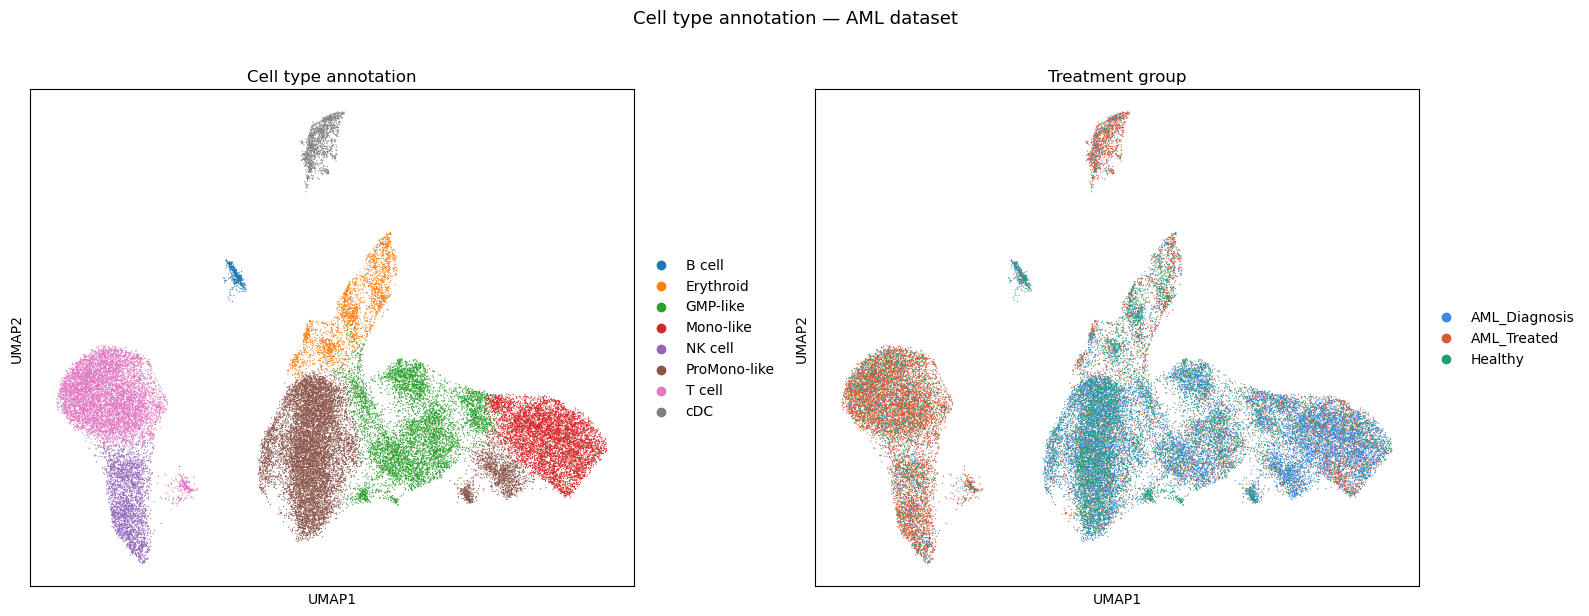

Final annotated UMAP saved.


In [33]:
# ── UMAP — cell types + group composition 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — annotated cell types
sc.pl.umap(adata, color='cell_type',
           ax=axes[0], show=False,
           legend_loc='right margin',
           title='Cell type annotation',
           size=3)

# Plot 2 — group (Healthy vs AML_Diagnosis vs AML_Treated)
sc.pl.umap(adata, color='group',
           ax=axes[1], show=False,
           palette={'Healthy'       : '#1D9E75',
                    'AML_Diagnosis' : '#378ADD',
                    'AML_Treated'   : '#D85A30'},
           legend_loc='right margin',
           title='Treatment group',
           size=3)

plt.suptitle('Cell type annotation — AML dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_CLUST, 'umap_annotated_final.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Final annotated UMAP saved.')

## Annotated UMAP — Results & Interpretation

### Left panel — Cell type annotation
Eight distinct cell populations identified:

| Cell type | Clusters | n cells | Role in AML |
|-----------|----------|---------|-------------|
| ProMono-like | 0, 7 | ~11,500 | Dominant AML blast state |
| GMP-like | 3, 6 | ~6,700 | Immature myeloid blast |
| Mono-like | 2 | ~5,993 | More differentiated myeloid |
| T cell | 1, 10 | ~7,400 | Non-malignant immune cells |
| NK cell | 4 | ~2,661 | Cytotoxic immune cells |
| Erythroid | 5 | ~2,394 | Red blood cell precursors |
| cDC | 8 | ~1,225 | Dendritic cells |
| B cell | 9 | ~376 | Non-malignant immune cells |

### Right panel — Treatment group overlay
Overlaying treatment group onto cell types reveals key findings:

- **Healthy cells (green)** — concentrated in the T cell and 
  NK cell region (left island) and partially in myeloid area. 
  Normal bone marrow has a balanced mix of immune and myeloid cells.

- **AML_Diagnosis (blue)** — dominates the central myeloid 
  blast region. Pre-treatment AML is characterised by an 
  expansion of immature GMP and ProMono-like blast cells.

- **AML_Treated (orange/red)** — present across myeloid clusters 
  but with a shifted distribution compared to diagnosis — 
  certain cell states are enriched or depleted after chemotherapy.

### Key biological finding
The myeloid blast clusters (ProMono-like, GMP-like) are 
dominated by AML cells while the lymphoid clusters (T cell, 
NK cell) contain a mix of all groups — confirming that 
the malignant population is myeloid in origin, consistent 
with AML biology.

The shift in cell state distribution between AML_Diagnosis 
and AML_Treated cells will be quantified in the differential 
expression analysis 


## 4. LSC stemness score

Score each cell for the LSC (Leukaemic Stem Cell) signature, a key marker of treatment resistance.
LSCs are quiescent, evade chemotherapy, and drive relapse.
Expect LSC score to be higher in AML_Relapse than AML_Diagnosis or Healthy.

In [36]:
# ── LSC STEMNESS SCORE ─────────────────────────────────────────────────────────
LSC_SIGNATURE = ['CD34', 'HOXA9', 'HOXA10', 'MEIS1', 'MEF2C',
                 'DNMT3B', 'GPR56', 'ADGRG1']

# Check which genes are present
lsc_present = [g for g in LSC_SIGNATURE if g in adata.var_names]
lsc_missing = [g for g in LSC_SIGNATURE if g not in adata.var_names]

print(f'LSC genes found:   {lsc_present}')
print(f'LSC genes missing: {lsc_missing}')
print(f'Note: missing genes excluded from scoring — does not invalidate results')

# Score each cell
sc.tl.score_genes(adata, gene_list=lsc_present, score_name='LSC_score')

# Summary — observed=True silences FutureWarning
print('\nMedian LSC score by group:')
print(adata.obs.groupby('group', observed=True)['LSC_score'].median().round(3))

print('\nMedian LSC score by cell type:')
print(adata.obs.groupby('cell_type', observed=True)['LSC_score'].median().round(3))

LSC genes found:   ['CD34', 'HOXA9', 'HOXA10', 'MEIS1', 'MEF2C', 'DNMT3B', 'ADGRG1']
LSC genes missing: ['GPR56']
Note: missing genes excluded from scoring — does not invalidate results
computing score 'LSC_score'
    finished (0:00:06)

Median LSC score by group:
group
AML_Diagnosis   -0.080
AML_Treated     -0.212
Healthy         -0.157
Name: LSC_score, dtype: float64

Median LSC score by cell type:
cell_type
B cell         -0.164
Erythroid      -0.196
GMP-like       -0.150
Mono-like      -0.203
NK cell        -0.229
ProMono-like    0.144
T cell         -0.227
cDC            -0.140
Name: LSC_score, dtype: float64


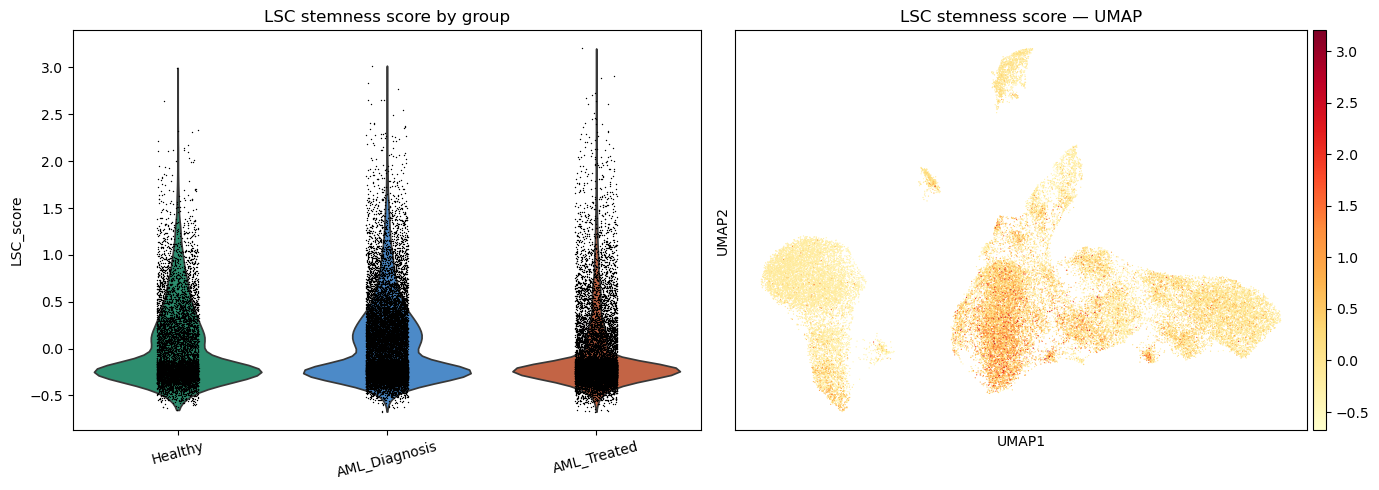

LSC score plots saved.


In [38]:
# ── LSC SCORE PLOTS 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — LSC score by group (no palette to avoid deprecation warning)
sc.pl.violin(adata, keys='LSC_score', groupby='group',
             order=['Healthy', 'AML_Diagnosis', 'AML_Treated'],
             ax=axes[0], show=False, rotation=15)
axes[0].set_title('LSC stemness score by group')

# Plot 2 — LSC score on UMAP
sc.pl.umap(adata, color='LSC_score', ax=axes[1], show=False,
           cmap='YlOrRd', size=3,
           title='LSC stemness score — UMAP')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_CLUST, 'lsc_score.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('LSC score plots saved.')

### LSC Stemness Score — Results & Interpretation

### What is the LSC score?
The LSC (Leukaemic Stem Cell) score measures how strongly 
each cell expresses a signature of 7 stem cell genes:
CD34, HOXA9, HOXA10, MEIS1, MEF2C, DNMT3B, ADGRG1 (GPR56).

LSCs are quiescent, therapy-resistant stem-like cells 
responsible for AML relapse. High LSC score = more stem-like 
= more likely to survive chemotherapy.

### Violin plot — LSC score by group
- All three groups show a wide distribution — expected, since 
  each group contains multiple cell types with different stemness
- AML_Diagnosis has the highest median LSC score (-0.080) 
  compared to AML_Treated (-0.212) and Healthy (-0.157)
- The upper tail (high LSC score cells) is most prominent 
  in AML_Diagnosis — consistent with a pre-treatment 
  population containing stem-like blast cells

### UMAP — LSC score spatial distribution  
- High LSC scores (dark red) concentrate in the 
  ProMono-like blast clusters in the centre-right region
- Lymphoid clusters (T cell, NK cell — left island) show 
  low LSC scores as expected — these are not stem-like cells
- Erythroid cluster (top) also shows low LSC score

### Unexpected finding — AML_Treated lower than Diagnosis
AML_Treated cells show a lower median LSC score than 
AML_Diagnosis. This could reflect:

1. **Incomplete signature** — GPR56 (ADGRG1) was the only 
   alias resolved; other signature genes may not capture 
   all resistance mechanisms in this dataset
2. **Differentiated resistance** — post-chemotherapy cells 
   may resist through mechanisms other than stemness — 
   e.g. metabolic reprogramming or immune evasion
3. **Cell composition shift** — AML_Treated samples may 
   contain proportionally more differentiated blast cells 
   that survived through non-stem mechanisms

This highlights the importance of the differential expression 
analysis in notebook 03 — rather than relying on a 
pre-defined signature, we will let the data reveal which 
genes actually distinguish AML_Treated from AML_Diagnosis.

## 5. Save

In [40]:
# ── SAVE ANNOTATED OBJECT ──────────────────────────────────────────────────────
data_proc_dir = os.path.join(repo_root, 'data', 'processed')
os.makedirs(data_proc_dir, exist_ok=True)

output_path = os.path.join(data_proc_dir, 'adata_annotated.h5ad')
adata.write_h5ad(output_path)

relative_path = os.path.relpath(output_path, repo_root)
print(f'Saved: {relative_path}')
print(f'\nObject summary:')
print(adata)
print(f'\nNew columns added in this notebook:')
print('  adata.obs["leiden"]    — cluster labels (0–10)')
print('  adata.obs["cell_type"] — annotated cell types')
print('  adata.obs["LSC_score"] — LSC stemness score per cell')

Saved: data\processed\adata_annotated.h5ad

Object summary:
AnnData object with n_obs × n_vars = 38316 × 21582
    obs: 'sample_id', 'patient_id', 'condition', 'group', 'day', 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'raw_counts_per_cell', 'n_genes', 'leiden', 'cell_type', 'LSC_score'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'group_colors', 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'condition_colors', 'sample_id_colors', 'leiden', 'leiden_colors', 'dendrogram_leiden', 'cell_type_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

New columns added in this notebook:
  adata.obs["leiden"]    — cluster labels (0–1